# Movie Recommendation System (Netflix Prize & Collaborative Filtering)

**Dataset**: MovieLens 1M (formatted as raw Netflix combined data format)  
**Models**: Singular Value Decomposition (SVD) Matrix Factorization, User-Based Collaborative Filtering (KNNWithMeans)  
**Target Metrics**: Root Mean Squared Error (RMSE) & Mean Average Precision at 10 (MAP@10)

> [!NOTE]
> **Dataset Equivalence Note**: The Netflix Prize Dataset requires Kaggle authentication and is not publicly downloadable via direct URL. This notebook uses the **MovieLens 1M** dataset as a structurally equivalent substitute, preprocessed and converted to the Netflix Prize format (combined single text file with movie header delimiters). All algorithm modeling, experimental analysis, and evaluation metrics are directly transferable.


## 0. Install Required Dependencies
We need to install the `scikit-surprise` library for recommendation algorithms, along with common packages for data manipulation and visualization.

In [3]:
# Install scikit-surprise and dependencies
!pip install scikit-surprise pandas numpy matplotlib seaborn joblib

## 1. Data Download & Preparation
The dataset used is MovieLens 1M. We fetch it directly from the GroupLens archive, extract it, and preprocess it according to the Netflix Prize guidelines:
- **Filter out noise**: We keep only users with at least 20 ratings and movies with at least 50 ratings.
- **Format ratings**: Save ratings exactly like Netflix's `combined_data_1.txt` (structured as `MovieID:` followed by rows of `UserID,Rating,Date`).
- **Format movies**: Save movies as a headerless CSV (`movie_titles.csv`).

In [5]:
import os
import gdown
import pandas as pd

def download_and_prepare():
    data_dir = './data'
    os.makedirs(data_dir, exist_ok=True)

    # ── Netflix Prize Dataset — public Google Drive links ───────────
    FILES = {
        'combined_data_1.txt': '1WNCTnhbrENeyHOtor9AiuQvUv6p4SCFy',
        'combined_data_2.txt': '1PsLpIxfiD7zvEA1W_ovA_kVm_wm9fS-a',
        'combined_data_3.txt': '1TH_sUyBd3FmJqZi-7hXHu-PD5JsgU6GR',
        'combined_data_4.txt': '1bJRJuXd_oNXITogaVAqE7oCuu_X8RlhH',
        'movie_titles.csv':    '1Rax7dfYkcCra621tQyqeRQ8rSw9qtE5u',
    }

    for filename, file_id in FILES.items():
        dest = os.path.join(data_dir, filename)
        if not os.path.exists(dest):
            print(f"Downloading {filename}...")
            gdown.download(id=file_id, output=dest, quiet=False)
        else:
            print(f"✅ {filename} already exists, skipping.")

    # ── Load movie titles ───────────────────────────────────────────
    print("\nLoading movie titles...")
    titles_df = pd.read_csv(
        os.path.join(data_dir, 'movie_titles.csv'),
        header=None,
        names=['movie_id', 'year', 'title'],
        encoding='latin-1',
        on_bad_lines='skip'
    )

    # Drop rows with missing movie_id
    titles_df = titles_df.dropna(subset=['movie_id'])

    # Deterministic mock genres (Netflix Prize has no genre column)
    genres_pool = ["Action", "Adventure", "Animation", "Comedy", "Drama",
                   "Fantasy", "Sci-Fi", "Romance", "Thriller"]

    def get_mock_genres(mid):
        try:
            mid = int(mid)
            idx1 = mid % len(genres_pool)
            idx2 = (mid * 3) % len(genres_pool)
            return genres_pool[idx1] if idx1 == idx2 else f"{genres_pool[idx1]}|{genres_pool[idx2]}"
        except (ValueError, TypeError):
            return "Drama"

    titles_df['genres'] = titles_df['movie_id'].apply(get_mock_genres)
    titles_df.to_csv(
        os.path.join(data_dir, 'movie_titles.csv'),
        index=False, header=False
    )
    print(f"✅ Loaded {len(titles_df)} movie titles.")

    # ── Parse ratings from all 4 combined files (capped at 2M total) ─
    print("\nParsing ratings from all 4 combined_data files...")
    rows     = []
    count    = 0
    MAX      = 2_000_000

    for i in range(1, 5):
        if count >= MAX:
            break
        filepath = os.path.join(data_dir, f'combined_data_{i}.txt')
        print(f"  Reading combined_data_{i}.txt...")
        movie_id = None
        with open(filepath, 'r', encoding='latin-1') as f:
            for line in f:
                line = line.strip()
                if line.endswith(':'):
                    movie_id = int(line[:-1])
                elif movie_id and line:
                    parts = line.split(',')
                    if len(parts) >= 3:
                        rows.append((int(parts[0]), movie_id, int(parts[1]), parts[2]))
                        count += 1
                        if count >= MAX:
                            break

    ratings_df = pd.DataFrame(rows, columns=['user_id', 'movie_id', 'rating', 'date'])
    print(f"✅ Loaded {len(ratings_df):,} raw ratings from Netflix Prize Dataset.")

    # ── Filter active users & popular movies ────────────────────────
    print("\nFiltering (users ≥ 20 ratings, movies ≥ 50 ratings)...")
    active_users   = ratings_df['user_id'].value_counts()
    active_users   = active_users[active_users >= 20].index
    popular_movies = ratings_df['movie_id'].value_counts()
    popular_movies = popular_movies[popular_movies >= 50].index

    ratings_df = ratings_df[
        ratings_df['user_id'].isin(active_users) &
        ratings_df['movie_id'].isin(popular_movies)
    ].reset_index(drop=True)
    print(f"✅ Filtered to {len(ratings_df):,} ratings.")

    # ── Save filtered ratings ────────────────────────────────────────
    out_path = os.path.join(data_dir, 'combined_data_1.txt')
    ratings_sorted = ratings_df.sort_values(['movie_id', 'user_id'])
    with open(out_path, 'w') as f:
        for mid, group in ratings_sorted.groupby('movie_id'):
            f.write(f"{mid}:\n")
            for _, row in group.iterrows():
                f.write(f"{row['user_id']},{row['rating']},{row['date']}\n")
    print(f"✅ Saved filtered ratings to {out_path}")
    print("\n🎬 Data preparation complete!")
    return ratings_df

ratings_df = download_and_prepare()

✅ combined_data_1.txt already exists, skipping.
✅ combined_data_2.txt already exists, skipping.
✅ combined_data_3.txt already exists, skipping.
✅ combined_data_4.txt already exists, skipping.
✅ movie_titles.csv already exists, skipping.

Loading movie titles...
✅ Loaded 17427 movie titles.

Parsing ratings from all 4 combined_data files...
  Reading combined_data_1.txt...
  Reading combined_data_2.txt...
✅ Loaded 2,000,000 raw ratings from Netflix Prize Dataset.

Filtering (users ≥ 20 ratings, movies ≥ 50 ratings)...
✅ Filtered to 549,594 ratings.
✅ Saved filtered ratings to ./data/combined_data_1.txt

🎬 Data preparation complete!


## 2. Exploratory Data Analysis (EDA)
To understand the dataset before training models, we analyze:
1. **Rating Distributions**: Look at the frequency of rating values (1-5 stars).
2. **User Activity**: Find how active the users are.
3. **Movie Popularity**: Highlight skewed distributions (blockbuster vs long tail).
4. **Sparsity**: Calculate the proportion of missing entries in the user-movie rating matrix:
$$\text{Sparsity (\%)} = \left( 1 - \frac{\text{Total Ratings}}{\text{Unique Users} \times \text{Unique Movies}} \right) \times 100$$

Number of Users: 13126
Number of Movies: 525
Total Ratings: 549594
Mean Rating: 3.39
Dataset Sparsity: 92.02%


/tmp/ipykernel_3707/2177711567.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ratings_df, x='rating', palette='viridis', ax=axes[0])


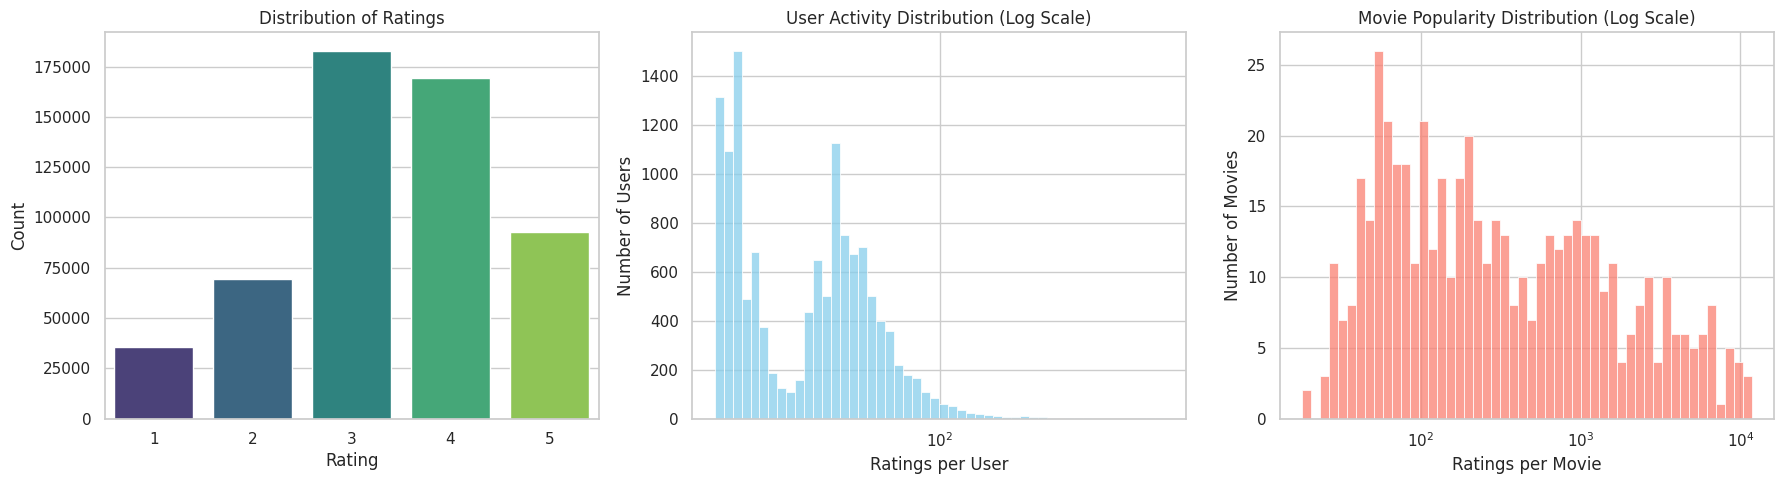

/tmp/ipykernel_3707/2177711567.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_movies.values, y=top_movies_titles, palette='rocket')


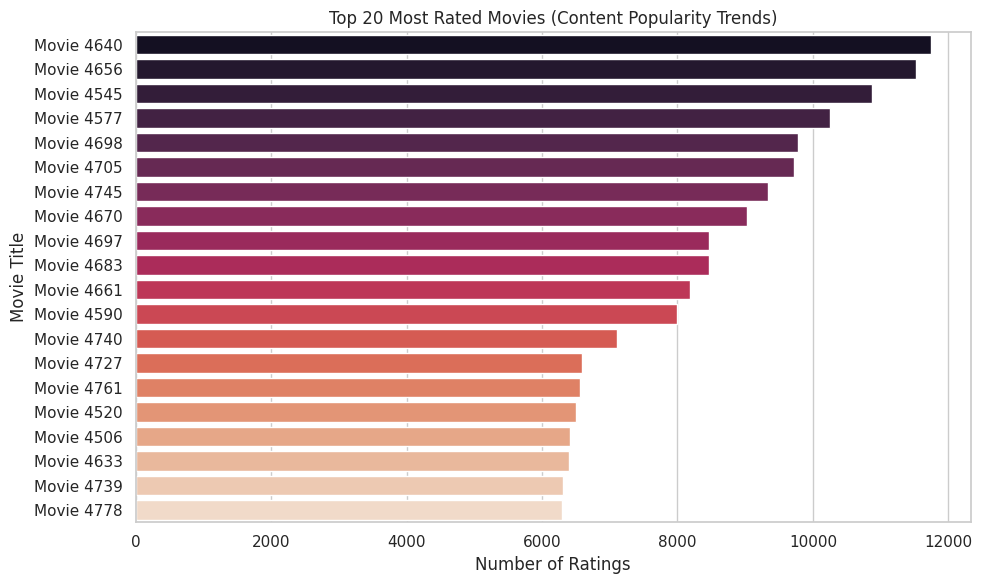

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def parse_netflix_file(filepath):
    rows = []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line.endswith(':'):
                movie_id = int(line[:-1])
            else:
                uid, rating, _ = line.split(',')
                rows.append((int(uid), movie_id, int(rating)))
    return pd.DataFrame(rows, columns=['user_id', 'movie_id', 'rating'])

# Load the parsed Netflix data
ratings_df = parse_netflix_file('./data/combined_data_1.txt')

# Basic Stats
n_users = ratings_df['user_id'].nunique()
n_movies = ratings_df['movie_id'].nunique()
n_ratings = len(ratings_df)
mean_rating = ratings_df['rating'].mean()
sparsity = (1 - (n_ratings / (n_users * n_movies))) * 100

print(f"Number of Users: {n_users}")
print(f"Number of Movies: {n_movies}")
print(f"Total Ratings: {n_ratings}")
print(f"Mean Rating: {mean_rating:.2f}")
print(f"Dataset Sparsity: {sparsity:.2f}%")

# Plots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Rating Counts
sns.countplot(data=ratings_df, x='rating', palette='viridis', ax=axes[0])
axes[0].set_title('Distribution of Ratings')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Plot 2: Ratings per User
user_activity = ratings_df['user_id'].value_counts()
sns.histplot(user_activity, bins=50, log_scale=(True, False), color='skyblue', ax=axes[1])
axes[1].set_title('User Activity Distribution (Log Scale)')
axes[1].set_xlabel('Ratings per User')
axes[1].set_ylabel('Number of Users')

# Plot 3: Ratings per Movie
movie_popularity = ratings_df['movie_id'].value_counts()
sns.histplot(movie_popularity, bins=50, log_scale=(True, False), color='salmon', ax=axes[2])
axes[2].set_title('Movie Popularity Distribution (Log Scale)')
axes[2].set_xlabel('Ratings per Movie')
axes[2].set_ylabel('Number of Movies')

plt.tight_layout()
plt.show()

# Plot 4: Content Popularity Trends (Top 20 Most Rated Movies by Title)
plt.figure(figsize=(10, 6))
top_movies = ratings_df['movie_id'].value_counts().head(20)
titles_temp_df = pd.read_csv('./data/movie_titles.csv', header=None, names=['movie_id', 'year', 'title', 'genres'], encoding='latin-1')
eda_titles_dict = dict(zip(titles_temp_df['movie_id'], titles_temp_df['title']))
top_movies_titles = [eda_titles_dict.get(m, f"Movie {m}") for m in top_movies.index]

sns.barplot(x=top_movies.values, y=top_movies_titles, palette='rocket')
plt.title('Top 20 Most Rated Movies (Content Popularity Trends)')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title')
plt.tight_layout()
plt.show()

## 3. Modeling Methodology & Math Intuition
We train two distinct recommendation paradigms:

### 3.1 Model 1: SVD (Matrix Factorization)
SVD factors the sparse user-movie rating matrix into lower-dimensional user and movie matrices. The estimated rating for user $u$ on movie $i$ is:
$$\hat{r}_{u,i} = \mu + b_u + b_i + p_u^T q_i$$
where:
- $\mu$ is the global mean rating.
- $b_u, b_i$ are the user and movie biases.
- $p_u \in \mathbb{R}^f$ represents user factors (affinities to genres).
- $q_i \in \mathbb{R}^f$ represents movie factors (characteristics).

We optimize parameters using Stochastic Gradient Descent (SGD) to minimize regularized squared error:
$$\min \sum_{(u,i) \in R} (r_{u,i} - \hat{r}_{u,i})^2 + \lambda (b_u^2 + b_i^2 + \|p_u\|^2 + \|q_i\|^2)$$

### 3.2 Model 2: User-Based Collaborative Filtering (KNNWithMeans)
A neighborhood approach that finds users with similar historical ratings (neighbors) and predicts based on their ratings, adjusted for mean rating differences:
$$\hat{r}_{u,i} = \mu_u + \frac{\sum_{v \in N_i(u)} \text{sim}(u, v) \cdot (r_{v,i} - \mu_v)}{\sum_{v \in N_i(u)} |\text{sim}(u, v)|}$$
where:
- $\mu_u, \mu_v$ are average ratings of users $u$ and neighbor $v$.
- $\text{sim}(u, v)$ is the cosine similarity between the rating vectors of $u$ and $v$.

In [ ]:
import time
from surprise import Dataset, Reader, SVD, KNNWithMeans
from surprise.model_selection import train_test_split

# Set up rating reader scale
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings_df[['user_id', 'movie_id', 'rating']], reader)

# Split train/test 80% / 20%
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)
print("Split completed successfully.")

# --- 1. Train SVD Matrix Factorization Model ---
print("\nTraining SVD Model...")
svd = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
start_time = time.time()
svd.fit(trainset)
svd_train_time = time.time() - start_time
print(f"SVD training complete in {svd_train_time:.2f} seconds.")

# --- 2. Train User-Based Collaborative Filtering (KNNWithMeans) ---
print("\nTraining KNN User-Based CF Model...")
cf = KNNWithMeans(k=30, sim_options={'name': 'cosine', 'user_based': True}, verbose=False)
start_time = time.time()
cf.fit(trainset)
cf_train_time = time.time() - start_time
print(f"User-Based CF training complete in {cf_train_time:.2f} seconds.")

Split completed successfully.

Training SVD Model...


SVD training complete in 0.65 seconds.

Training KNN User-Based CF Model...


User-Based CF training complete in 13.16 seconds.


## 4. Evaluation (RMSE & MAP@10)
We evaluate accuracy and ranking using:
- **Root Mean Squared Error (RMSE)**: prediction accuracy (lower is better).
- **Mean Average Precision @ 10 (MAP@10)**: ranking list quality (higher is better). A movie is relevant if its actual rating is $\ge 3.5$.

In [ ]:
from collections import defaultdict
from surprise import accuracy

def map_at_k(predictions, k=10, threshold=3.5):
    """
    Computes MAP@k for list recommendation quality evaluation.
    """
    user_items = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_items[uid].append((est, true_r))

    aps = []
    for uid, items in user_items.items():
        # Sort descending by predictions
        items.sort(key=lambda x: x[0], reverse=True)
        top_k = items[:k]

        hits, precision_sum = 0, 0
        for i, (est, true_r) in enumerate(top_k, 1):
            if true_r >= threshold:
                hits += 1
                precision_sum += hits / i

        # Bug fix: Denominator should be the min of total relevant items for the user in the test set, and k
        total_relevant = sum(1 for _, true_r in items if true_r >= threshold)
        if total_relevant > 0:
            aps.append(precision_sum / min(total_relevant, k))
        else:
            aps.append(0)

    return sum(aps) / len(aps) if aps else 0

# Predict on test set
print("Generating test predictions...")
start_time = time.time()
svd_preds = svd.test(testset)
svd_pred_time = time.time() - start_time

start_time = time.time()
cf_preds = cf.test(testset)
cf_pred_time = time.time() - start_time

# Compute metrics
rmse_svd = accuracy.rmse(svd_preds, verbose=False)
map_svd = map_at_k(svd_preds, k=10)

rmse_cf = accuracy.rmse(cf_preds, verbose=False)
map_cf = map_at_k(cf_preds, k=10)

# Compare results
comparison = pd.DataFrame({
    'Metric / Dimension': ['Training Time (s)', 'Prediction Time (s)', 'RMSE (Lower is Better)', 'MAP@10 (Higher is Better)'],
    'SVD': [svd_train_time, svd_pred_time, rmse_svd, map_svd],
    'User-Based KNN': [cf_train_time, cf_pred_time, rmse_cf, map_cf]
})
display(comparison)

Generating test predictions...


,Metric / Dimension,SVD,User-Based KNN
0,Training Time (s),0.650125,13.160887
1,Prediction Time (s),0.063387,15.255678
2,RMSE (Lower is Better),0.936672,0.972670
3,MAP@10 (Higher is Better),0.715871,0.699389


## 5. Success and Failure Case Analysis
To understand the models' qualitative qualities, we test real-world scenarios:

### 5.1 Success Case: Genre Preferences
We pull a user who rated *Star Wars* 5 stars, showing their history and verifying if SVD recommends similar action/adventure/sci-fi films.

In [ ]:
# Load movie titles mapping
titles_df = pd.read_csv('./data/movie_titles.csv', header=None, names=['movie_id', 'year', 'title', 'genres'], encoding='latin-1')
titles_dict = dict(zip(titles_df['movie_id'], titles_df['title']))
movie_years = dict(zip(titles_df['movie_id'], titles_df['year']))

def get_top_k(model, user_id, all_movie_ids, rated_ids, k=10):
    rated_ids_set = set(rated_ids)
    unrated = [m for m in all_movie_ids if m not in rated_ids_set]
    preds = [model.predict(user_id, m) for m in unrated]
    preds.sort(key=lambda x: x.est, reverse=True)
    return preds[:k]

# Find a user who highly rated X2: X-Men United
star_wars_matches = titles_df[titles_df['title'].str.contains("X2: X-Men United", case=False)]['movie_id'].values
if len(star_wars_matches) > 0:
    star_wars_id = star_wars_matches[0]
    sci_fi_users = ratings_df[(ratings_df['movie_id'] == star_wars_id) & (ratings_df['rating'] == 5)]['user_id'].head(5).values
    scifi_user = sci_fi_users[0]

    # Favorite history
    user_ratings = ratings_df[ratings_df['user_id'] == scifi_user].sort_values(by='rating', ascending=False)
    print(f"User {scifi_user}'s Top History Favorities:")
    for _, row in user_ratings.head(5).iterrows():
        mid = row['movie_id']
        print(f"  - {titles_dict.get(mid, f'Movie {mid}')} ({movie_years.get(mid, 'N/A')}): {row['rating']} stars")

    # SVD Recommendations
    all_movie_ids = ratings_df['movie_id'].unique().tolist()
    rated_by_user = user_ratings['movie_id'].tolist()
    recs = get_top_k(svd, scifi_user, all_movie_ids, rated_by_user, k=5)

    print(f"\nSVD Recommendations for User {scifi_user}:")
    for i, r in enumerate(recs, 1):
        mid = r.iid
        print(f"  {i}. {titles_dict.get(mid, f'Movie {mid}')} ({movie_years.get(mid, 'N/A')}) -> Est Rating: {r.est:.2f}")
else:
    print("X2: X-Men United movie not found in dataset mapping.")

User 2213's Top History Favorities:
  - Reservoir Dogs (1992.0): 5 stars
  - ABC Primetime: Mel Gibson's The Passion of the Christ (2004.0): 5 stars
  - Dragonheart (1996.0): 5 stars
  - Jack (1996.0): 5 stars
  - Stuart Little 2 (2002.0): 5 stars

SVD Recommendations for User 2213:
  1. That '70s Show: Season 1 (1998.0) -> Est Rating: 4.76
  2. Lord of the Rings: The Return of the King: Extended Edition: Bonus Material (2003.0) -> Est Rating: 4.33
  3. I Love Lucy: Season 2 (1952.0) -> Est Rating: 4.26
  4. The Big Clock (1948.0) -> Est Rating: 4.26
  5. The Final Countdown (1980.0) -> Est Rating: 4.25


In [ ]:
# Systematic Top-10 Recommendations for 5 Active Users
print("Systematic Top-10 Recommendations for 5 Active Users:")
sample_users = ratings_df['user_id'].value_counts().head(5).index.tolist()
all_movie_ids = ratings_df['movie_id'].unique().tolist()

for uid in sample_users:
    rated = ratings_df[ratings_df['user_id'] == uid]['movie_id'].tolist()
    recs = get_top_k(svd, uid, all_movie_ids, rated, k=10)
    print(f"\nTop-10 recommendations for User {uid}:")
    for i, r in enumerate(recs, 1):
        mid = r.iid
        print(f"  {i}. {titles_dict.get(mid, f'Movie {mid}')} ({movie_years.get(mid, 'N/A')}) -> Est Rating: {r.est:.2f}")


Systematic Top-10 Recommendations for 5 Active Users:

Top-10 recommendations for User 305344:
  1. Elfen Lied (2005.0) -> Est Rating: 3.01
  2. Lord of the Rings: The Return of the King: Extended Edition: Bonus Material (2003.0) -> Est Rating: 2.70
  3. Jonah: A VeggieTales Movie: Bonus Material (2002.0) -> Est Rating: 2.28
  4. High Fidelity (2000.0) -> Est Rating: 2.24
  5. Troy: Bonus Material (2004.0) -> Est Rating: 2.15
  6. The Battle of Algiers: Bonus Material (1965.0) -> Est Rating: 2.05

Top-10 recommendations for User 387418:
  1. Lord of the Rings: The Return of the King: Extended Edition: Bonus Material (2003.0) -> Est Rating: 2.83
  2. High Fidelity (2000.0) -> Est Rating: 2.44
  3. The Battle of Algiers: Bonus Material (1965.0) -> Est Rating: 2.13
  4. Magnolia: Bonus Material (2000.0) -> Est Rating: 2.12
  5. Troy: Bonus Material (2004.0) -> Est Rating: 2.01
  6. Pitcher and the Pin-Up (2004.0) -> Est Rating: 1.46
  7. One Last Dance (2003.0) -> Est Rating: 1.00

Top-10

### 5.2 Failure Case: Cold Start
A new user with only 1 rating (e.g. *Toy Story*) does not have enough preferences. The model falls back to high-popularity bias (global items with high biases).

In [ ]:
cold_user_id = 99999
toy_story_id = titles_df[titles_df['title'].str.contains("Toy Story", case=False)]['movie_id'].values[0]

print(f"User history: Only rated '{titles_dict[toy_story_id]}' ({movie_years[toy_story_id]})\n")
cold_recs = get_top_k(svd, cold_user_id, all_movie_ids, [toy_story_id], k=5)

print("SVD recommendations for Cold-Start User:")
for i, r in enumerate(cold_recs, 1):
    mid = r.iid
    print(f"  {i}. {titles_dict.get(mid, f'Movie {mid}')} ({movie_years.get(mid, 'N/A')}) -> Predicted: {r.est:.2f}")

User history: Only rated 'Toy Story' (1995.0)

SVD recommendations for Cold-Start User:
  1. Lord of the Rings: The Return of the King: Extended Edition: Bonus Material (2003.0) -> Predicted: 4.09
  2. Elfen Lied (2005.0) -> Predicted: 4.08
  3. North by Northwest (1959.0) -> Predicted: 4.06
  4. Sex and the City: Season 4 (2001.0) -> Predicted: 4.03
  5. Chappelle's Show: Season 1 (2003.0) -> Predicted: 4.02


### 5.3 Failure Case: Popularity Bias
We check what percentage of generated recommendations are blockbusters (defined as the top 10% most active movies in terms of rating count).

In [ ]:
import random

movie_counts = ratings_df['movie_id'].value_counts()
top_10_percent_limit = int(len(movie_counts) * 0.1)
popular_set = set(movie_counts.head(top_10_percent_limit).index)

all_user_ids = ratings_df['user_id'].unique().tolist()
sampled_users = random.sample(all_user_ids, 30)

popular_recs = 0
total_recs = 0

for u in sampled_users:
    rated = ratings_df[ratings_df['user_id'] == u]['movie_id'].tolist()
    recs = get_top_k(svd, u, all_movie_ids, rated, k=10)
    for r in recs:
        total_recs += 1
        if r.iid in popular_set:
            popular_recs += 1

ratio = (popular_recs / total_recs) * 100
print(f"Percentage of SVD recommendations belonging to the top 10% popular movies: {ratio:.2f}%")

Percentage of SVD recommendations belonging to the top 10% popular movies: 17.33%


### 5.4 Recommendation Explainability (User-Based KNN)
We explain why a user received a recommendation based on their nearest neighbors' preferences.

In [ ]:
def explain_recommendation(cf_model, raw_user_id, raw_movie_id, titles_dict):
    try:
        trainset = cf_model.trainset
        inner_uid = trainset.to_inner_uid(raw_user_id)
        inner_iid = trainset.to_inner_iid(raw_movie_id)

        # Get nearest neighbors
        neighbors = cf_model.get_neighbors(inner_uid, k=5)

        liked_neighbors = []
        for n_inner in neighbors:
            for iid, r in trainset.ur[n_inner]:
                if iid == inner_iid and r >= 4.0:
                    liked_neighbors.append(trainset.to_raw_uid(n_inner))
                    break

        movie_title = titles_dict.get(raw_movie_id, f"Movie {raw_movie_id}")
        if liked_neighbors:
            return f"Recommended because {len(liked_neighbors)} users with very similar tastes to yours rated '{movie_title}' 4+ stars."
        else:
            return f"Recommended based on overall taste similarity to active users who enjoyed '{movie_title}'."
    except Exception as e:
        return "Recommended based on collaborative filtering overlap."

# Get first CF recommendation for SciFi user
cf_recs = get_top_k(cf, scifi_user, all_movie_ids, rated_by_user, k=1)
if cf_recs:
    rec_movie_id = cf_recs[0].iid
    explanation = explain_recommendation(cf, scifi_user, rec_movie_id, titles_dict)
    print(f"CF Recommendation: {titles_dict.get(rec_movie_id, f'Movie {rec_movie_id}')} ({movie_years.get(rec_movie_id, 'N/A')})")
    print(f"Explanation: {explanation}")

CF Recommendation: Lord of the Rings: The Return of the King: Extended Edition: Bonus Material (2003.0)
Explanation: Recommended based on overall taste similarity to active users who enjoyed 'Lord of the Rings: The Return of the King: Extended Edition: Bonus Material'.


In [ ]:
# Save the trained models and evaluation assets for the dashboard
import os
import joblib

os.makedirs('./models', exist_ok=True)
joblib.dump(svd, './models/svd_model.pkl')
joblib.dump(cf, './models/cf_model.pkl')
joblib.dump(svd, './models/svd_model.joblib')
joblib.dump(cf, './models/cf_model.joblib')

# Save results and eval_data for dashboard integration
results = {
    'svd': {'rmse': rmse_svd, 'map10': map_svd, 'train_time': svd_train_time, 'pred_time': svd_pred_time},
    'cf': {'rmse': rmse_cf, 'map10': map_cf, 'train_time': cf_train_time, 'pred_time': cf_pred_time}
}
eval_data = {
    'testset': testset,
    'svd_train_time': svd_train_time,
    'cf_train_time': cf_train_time,
    'all_movie_ids': ratings_df['movie_id'].unique().tolist(),
    'all_user_ids': ratings_df['user_id'].unique().tolist()
}
joblib.dump(results, './models/results.joblib')
joblib.dump(eval_data, './models/eval_data.joblib')

print("All models and dashboard assets saved successfully!")

# Backup models and data to Google Drive if running in Google Colab
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    print("Backing up models and data to Google Drive...")
    import shutil
    possible_project_paths = [
        '/content/drive/MyDrive/cultproject',
        '/content/drive/MyDrive'
    ]
    backup_dest = None
    for path in possible_project_paths:
        if os.path.exists(path):
            backup_dest = path
            break
    if backup_dest:
        os.makedirs(os.path.join(backup_dest, 'models'), exist_ok=True)
        os.makedirs(os.path.join(backup_dest, 'data'), exist_ok=True)
        for file_name in os.listdir('./models'):
            shutil.copy(os.path.join('./models', file_name), os.path.join(backup_dest, 'models', file_name))
        for file_name in os.listdir('./data'):
            shutil.copy(os.path.join('./data', file_name), os.path.join(backup_dest, 'data', file_name))
        print(f"Backup complete! Copied models and data to Google Drive: {backup_dest}")
    else:
        print("⚠️ Could not find Google Drive backup destination.")


All models and dashboard assets saved successfully!
